In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Veri Yükleme
df = pd.read_csv("/content/drive/MyDrive/HSD Final Task/credit_customers.csv")

In [36]:
# IQR Yöntemiyle Aykırı Değer Temizliği
sayisal_sutunlar = ["credit_amount", "duration", "age"]
aykiri_deger_maskesi = pd.Series(False, index=df.index)

for sutun in sayisal_sutunlar:
    q1 = df[sutun].quantile(0.25)
    q3 = df[sutun].quantile(0.75)
    iqr = q3 - q1
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr
    aykiri_deger_maskesi = aykiri_deger_maskesi | (df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)

df_clean = df.loc[~aykiri_deger_maskesi].copy().reset_index(drop=True)

# Target Encoding ve One-Hot Encoding
df_clean["target"] = df_clean["class"].map({"good": 0, "bad": 1})
df_eda = df_clean.copy()

kategorik_sutunlar = df_clean.select_dtypes(include=["object"]).columns.drop("class").tolist()
df_encoded = pd.get_dummies(df_clean.drop(columns=["class"]), columns=kategorik_sutunlar, drop_first=True, dtype=int)

/tmp/ipykernel_3401/2541902996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x="class", palette=["#4CB391", "#E74C3C"])


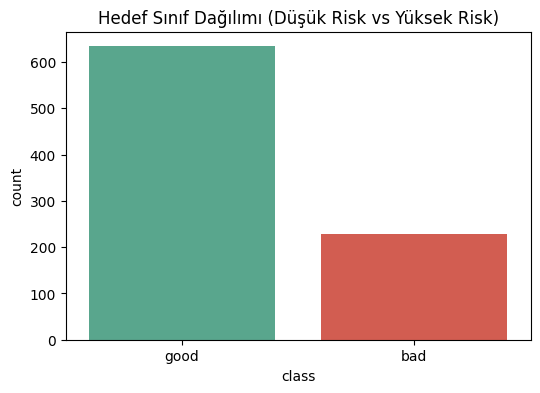

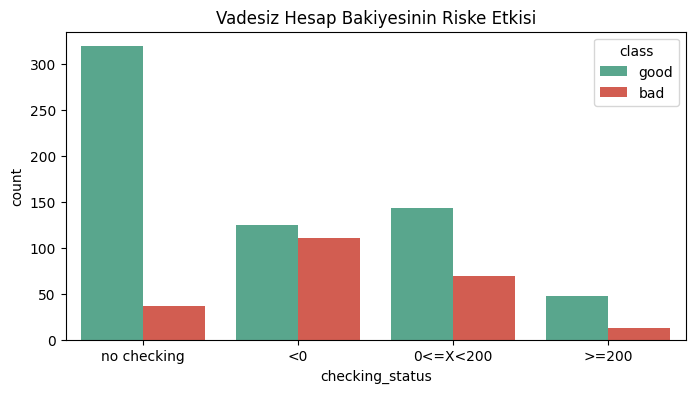

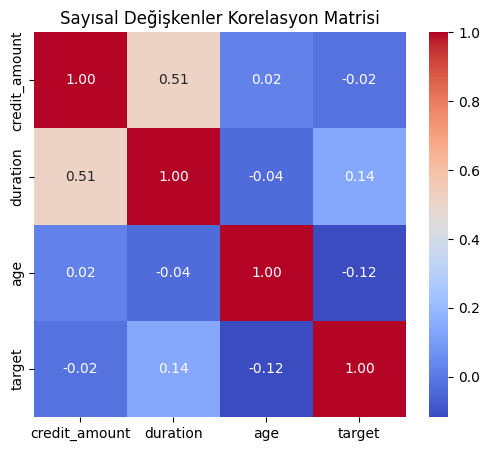

In [37]:
# Kredi Riski Sınıf Dağılımı
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x="class", palette=["#4CB391", "#E74C3C"])
plt.title("Hedef Sınıf Dağılımı (Düşük Risk vs Yüksek Risk)")
print()
plt.show()

# Vadesiz Hesap Durumu
plt.figure(figsize=(8, 4))
sns.countplot(data=df_eda, x="checking_status", hue="class", palette=["#4CB391", "#E74C3C"])
plt.title("Vadesiz Hesap Bakiyesinin Riske Etkisi")
print()
plt.show()

# Korelasyon Matrisi
sayisal_df = df_eda[sayisal_sutunlar + ["target"]]
plt.figure(figsize=(6, 5))
sns.heatmap(sayisal_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
print()
plt.show()

In [38]:
X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tree_clf = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

tree_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)
rf_prob = rf_clf.predict_proba(X_test)[:, 1]

print("--- Random Forest Sınıflandırma Raporu ---")
print(classification_report(y_test, rf_pred, target_names=["Düşük Risk (0)", "Yüksek Risk (1)"]))

--- Random Forest Sınıflandırma Raporu ---
                 precision    recall  f1-score   support

 Düşük Risk (0)       0.76      0.98      0.86       127
Yüksek Risk (1)       0.75      0.13      0.22        46

       accuracy                           0.76       173
      macro avg       0.75      0.56      0.54       173
   weighted avg       0.76      0.76      0.69       173



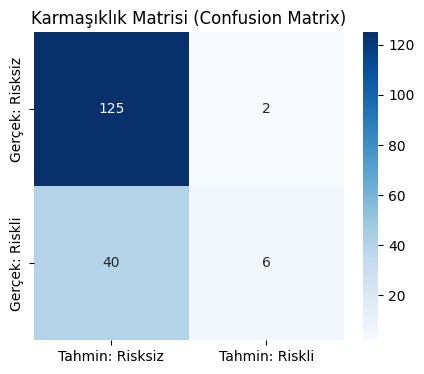

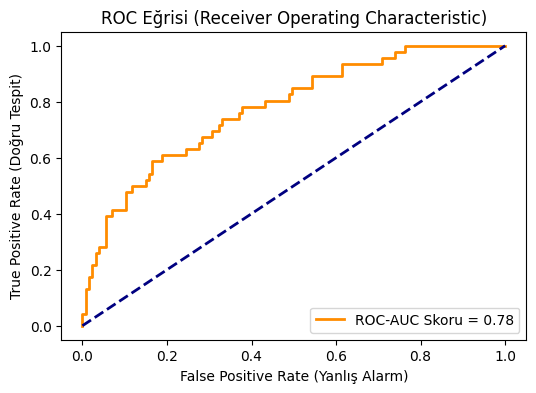

In [41]:
# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tahmin: Risksiz", "Tahmin: Riskli"],
            yticklabels=["Gerçek: Risksiz", "Gerçek: Riskli"])
plt.title("Karmaşıklık Matrisi (Confusion Matrix)")
print()
plt.show()

# ROC-AUC Eğrisi
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
roc_auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC-AUC Skoru = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.title("ROC Eğrisi (Receiver Operating Characteristic)")
plt.xlabel("False Positive Rate (Yanlış Alarm)")
plt.ylabel("True Positive Rate (Doğru Tespit)")
plt.legend(loc="lower right")
print()
plt.show()

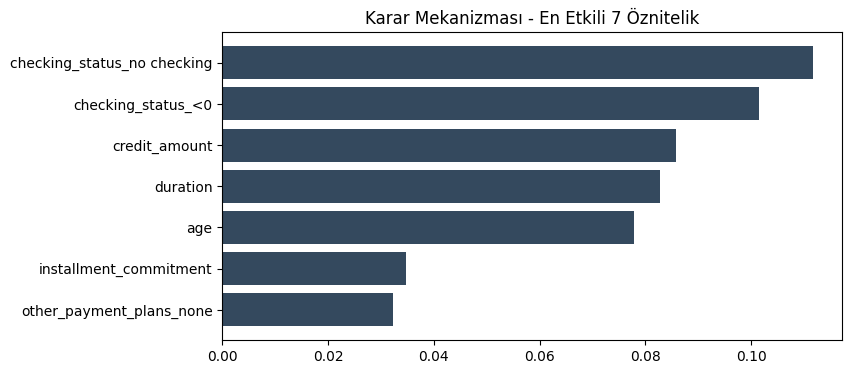

In [42]:
# Feature Importance
importances = rf_clf.feature_importances_
feature_names = X.columns
sorted_indices = np.argsort(importances)[::-1][:7]

plt.figure(figsize=(8, 4))
plt.title("Karar Mekanizması - En Etkili 7 Öznitelik")
plt.barh(range(len(sorted_indices)), importances[sorted_indices][::-1], color="#34495E")
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices][::-1])
plt.show()